# 07 — Tổng hợp: một tấm ảnh tốn bao nhiêu, và nên kéo đòn bẩy nào

Notebook cuối ghép các mảnh của cả bộ lại thành câu trả lời cho câu hỏi của dự án: **chạy một mô
hình thị giác–ngôn ngữ trên GPU 6 GB, thời gian nằm ở đâu, và đòn bẩy nào đáng kéo?**

| Mục | Nội dung | Dựa trên |
|---|---|---|
| 1 | Một tấm ảnh thành bao nhiêu token | notebook 03 |
| 2 | Thời gian nằm ở đâu — đo trên máy này | notebook 02, 04 |
| 3 | Bản đồ đòn bẩy: dự đoán và đo thực tế | notebook 02 (Amdahl), 05 |
| 4 | Biểu đồ đánh đổi, với khoảng tin cậy đúng | notebook 00, 01 (lỗi 5) |
| 5 | Kết luận kỹ thuật | cả bộ |

In [1]:
import json, sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")                      # main-branch code lives one level up
from bench.harness import load_samples, PROMPT
from bench.metrics import wilson_interval, paired_accuracy

RESULTS = Path("../results")
plt.rcParams.update({"figure.figsize": (7, 3.6), "figure.dpi": 110})
dev = "cuda"

def load(name):
    return json.loads((RESULTS / name).read_text())

## 1. Một tấm ảnh thành bao nhiêu token

Mô hình ngôn ngữ chỉ nhận một chuỗi vector. Ảnh được biến thành vector cùng số chiều với embedding
chữ rồi **chèn thẳng vào chuỗi** (notebook 03): cắt thành 13 ô, mỗi ô 729 mảnh qua bộ mã hoá, pixel
shuffle nén còn 81 token mỗi ô.

In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText
MODEL = "HuggingFaceTB/SmolVLM-Instruct"
proc = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to(dev).eval()

sample = load_samples(1, seed=0)[0]
msg = [{"role": "user", "content": [{"type": "image"},
                                    {"type": "text", "text": PROMPT.format(q=sample["query"])}]}]
inputs = proc(text=proc.apply_chat_template(msg, add_generation_prompt=True),
              images=[sample["image"]], return_tensors="pt").to(dev)
ids = inputs["input_ids"][0]
n_img = int((ids == model.config.image_token_id).sum())
print(f"image {sample['image'].size} -> {inputs['pixel_values'].shape[1]} tiles")
print(f"input sequence: {ids.numel()} tokens, of which image tokens {n_img} ({100 * n_img / ids.numel():.1f}%)")
print(f"patches through the vision encoder: {inputs['pixel_values'].shape[1] * 729}")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

image (800, 557) -> 13 tiles
input sequence: 1251 tokens, of which image tokens 1053 (84.2%)
patches through the vision encoder: 9477


Ảnh chiếm hơn 80% chuỗi đầu vào. Câu hỏi, khuôn mẫu hội thoại và chỉ dẫn cộng lại chỉ khoảng 200
token. Nhưng như notebook 03 chỉ ra, con số thật sự đắt là **9.477 mảnh** đi qua bộ mã hoá, không
phải 1.053 token mô hình ngôn ngữ nhìn thấy.

## 2. Thời gian nằm ở đâu

Đo từng thành phần bằng CUDA event (notebook 02), sau khi làm nóng. Pha cuối là **sinh câu trả lời**:
`max_new_tokens=32` chỉ là giới hạn trên, câu trả lời ngắn dừng sớm (notebook 04, mục 5.1).

In [3]:
def timed(fn, reps=5):
    for _ in range(2): fn()
    ts, out = [], None
    for _ in range(reps):
        s, e = torch.cuda.Event(True), torch.cuda.Event(True)
        torch.cuda.synchronize(); s.record(); out = fn(); e.record(); torch.cuda.synchronize()
        ts.append(s.elapsed_time(e))
    return float(np.median(ts)), out

inner = model.model
pix = inputs["pixel_values"].flatten(0, 1).to(model.dtype)
gen = lambda: model.generate(**inputs, max_new_tokens=32, do_sample=False)
with torch.no_grad():
    t_vis, vis_out = timed(lambda: inner.vision_model(pixel_values=pix))
    t_con, _ = timed(lambda: inner.connector(vis_out.last_hidden_state))
    t_fwd, _ = timed(lambda: model(**inputs))                # vision + connector + LM prefill
    t_gen, out = timed(gen)
n_new = out.shape[1] - ids.numel()
parts = {"vision encoder": t_vis, "connector": t_con, "LM prefill": t_fwd - t_vis - t_con,
         f"generate the answer ({n_new} tokens)": t_gen - t_fwd}
for k, v in parts.items():
    print(f"{k:<32} {v:7.1f} ms  {100 * v / t_gen:5.1f}%")
print(f"{'total':<32} {t_gen:7.1f} ms")
print("answer:", proc.decode(out[0, ids.numel():], skip_special_tokens=True).strip(), "| gold:", sample["gold"])
del model; torch.cuda.empty_cache()

vision encoder                     480.7 ms   52.4%
connector                            2.4 ms    0.3%
LM prefill                         238.6 ms   26.0%
generate the answer (7 tokens)     195.2 ms   21.3%
total                              916.8 ms
answer: 2022. | gold: 2022


Kết quả khớp với bảng phân rã của dự án (đo trên 12 câu hỏi): **bộ mã hoá thị giác chiếm hơn một
nửa**, prefill của mô hình ngôn ngữ khoảng một phần tư đến một phần ba, phần sinh câu trả lời
phần còn lại. (Con số của
một lần chạy dao động vài phần trăm — notebook 02.)

Mỗi pha bị giới hạn bởi một tài nguyên khác nhau (notebook 04, 05):

| Pha | Giới hạn bởi | Vì sao |
|---|---|---|
| Mã hoá thị giác | tính toán | 9.477 mảnh × 413 triệu tham số ≈ 8,7 TFLOP |
| Prefill ngôn ngữ | tính toán | 1.251 token × 1,6 tỉ tham số ≈ 4,2 TFLOP |
| Sinh câu trả lời | băng thông bộ nhớ (bf16), CPU (nf4) | mỗi token đọc toàn bộ trọng số; ~1.000 kernel mỗi token |

## 3. Bản đồ đòn bẩy

Mỗi đòn bẩy của dự án tác động vào một số pha. Định luật Amdahl (notebook 02) cho dự đoán; các file
kết quả cho con số đo được. Độ chính xác so theo cặp với bản gốc **của cùng lần chạy** (notebook 00):

In [4]:
shares = load("breakdown.json")["share_pct"]
p_pre, p_img = shares["llm_prefill"] / 100, (shares["vision"] + shares["connector"] + shares["llm_prefill"]) / 100
amdahl = lambda p, s: 1 / ((1 - p) + p / s)

def lever(run, cfg):
    r = load(run)
    pa = paired_accuracy(r["records"], "baseline", cfg)
    d = 100 * (r["configs"][cfg]["accuracy"] - r["configs"]["baseline"]["accuracy"])
    return r["paired_speedup_vs_baseline"][cfg]["median_speedup"], d, pa["p_value"], pa["n_pairs"]

rows = [
    ("edge 768 (13 -> 5 tiles)", "vision + prefill", amdahl(p_img, 13 / 5), *lever("gate2_confirm.json", "edge768(edge=768)")),
    ("no splitting (1 tile)", "vision + prefill", amdahl(p_img, 13), *lever("gate2_edge_sweep.json", "nosplit(nosplit)")),
    ("prune to 50% after encoder", "prefill only", amdahl(p_pre, 2), *lever("gate2_sweep.json", "keep0.5:uniform(keep=0.5,uniform)")),
    ("prune to 25% after encoder", "prefill only", amdahl(p_pre, 4), *lever("gate2_sweep.json", "keep0.25:uniform(keep=0.25,uniform)")),
]
print(f"{'lever':<28} {'touches':<17} {'Amdahl':>7} {'measured':>9} {'accuracy':>9} {'p':>7} {'n':>4}")
for name, touches, pred, sp, d, p, n in rows:
    print(f"{name:<28} {touches:<17} {pred:6.2f}x {sp:8.2f}x {d:+8.1f} {p:7.3f} {n:>4}")

nf4, bf = load("gate5_nf4_300.json"), load("gate2_confirm.json")
t_nf4, t_bf = nf4["configs"]["baseline"]["generate_ms"]["median"], bf["configs"]["baseline"]["generate_ms"]["median"]
pa = paired_accuracy([dict(r, config="bf16") for r in bf["records"] if r["config"] == "baseline"] +
                     [dict(r, config="nf4") for r in nf4["records"] if r["config"] == "baseline"], "bf16", "nf4")
print(f"{'nf4 weights':<28} {'all (bytes only)':<17} {'  -':>7} {t_bf / t_nf4:8.2f}x "
      f"{100 * (nf4['configs']['baseline']['accuracy'] - bf['configs']['baseline']['accuracy']):+8.1f} "
      f"{pa['p_value']:7.3f} {pa['n_pairs']:>4}   VRAM {bf['peak_vram_mb']:.0f} -> {nf4['peak_vram_mb']:.0f} MiB")

lever                        touches            Amdahl  measured  accuracy       p    n
edge 768 (13 -> 5 tiles)     vision + prefill    2.02x     1.93x     -7.3   0.002  300
no splitting (1 tile)        vision + prefill    4.13x     2.08x    -28.0   0.000  100
prune to 50% after encoder   prefill only        1.17x     1.13x    -12.5   0.125   40
prune to 25% after encoder   prefill only        1.28x     1.20x    -25.0   0.013   40
nf4 weights                  all (bytes only)        -     0.91x     -4.0   0.081  300   VRAM 5213 -> 2321 MiB


Đọc bảng theo cột "touches" (tác động vào pha nào):

- **Đòn bẩy chạm vào bộ mã hoá** (giảm số ô) cho tăng tốc lớn nhất. Cạnh 768 gần sát dự đoán
  Amdahl. Với "không cắt ô" (13 ô còn 1), dự đoán khoảng 4× nhưng đo được chỉ khoảng 2×, vì dự đoán
  giả định cả bộ mã hoá lẫn prefill cùng nhỏ đi 13 lần, trong khi thực tế:
  (1) khoảng 200 token chữ vẫn còn nguyên, nên prefill chỉ giảm từ 1.251 xuống khoảng 280 token
  (khoảng 4,5 lần);
  (2) một ô đơn lẻ dùng GPU kém hiệu quả hơn một lô 13 ô (notebook 03, mục 6).
  Cái giá là độ chính xác mất gần 30 điểm: ở 384×384, chữ số trên biểu đồ không còn đọc được. Bài
  học: định luật Amdahl chỉ đúng khi giả định "phần đó nhỏ đi $s$ lần" đúng — phải kiểm tra lại $s$
  thật.
- **Đòn bẩy chỉ chạm vào prefill** (cắt token sau bộ mã hoá) bị Amdahl chặn ở 1,42×, và đo được còn
  thấp hơn dự đoán — nhưng vẫn mất độ chính xác đáng kể.
- **nf4** không chạm vào FLOP nào; nó giảm byte. Kết quả: bộ nhớ giảm hơn một nửa, thời gian **tăng**
  (notebook 05: prefill thêm giải lượng tử, decode bị giới hạn bởi CPU).

(Các dòng cắt token chỉ có 40 câu hỏi — lực kiểm định thấp, nên p lớn không có nghĩa là không mất
độ chính xác; notebook 00, mục 6.)

## 4. Biểu đồ đánh đổi, với khoảng tin cậy đúng

Biểu đồ trong README lấy khoảng tin cậy từ file kết quả, vốn tính với $n$ = số bản ghi thay vì số câu
hỏi (notebook 01, lỗi 5). Vẽ lại từ lần quét 40 câu × 3 vòng, với $n = 40$ — số quan sát độc lập:

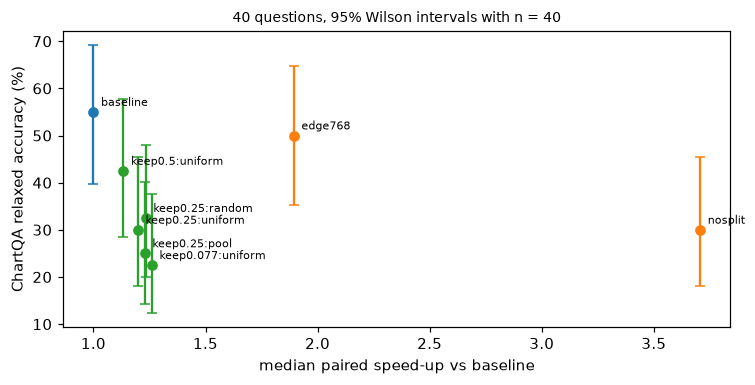

In [5]:
sweep = load("gate2_sweep.json")
per = defaultdict(lambda: defaultdict(list))
for r in sweep["records"]:
    per[r["config"]][r["sample_id"]].append(int(r["correct"]))
fam = {"baseline": "C0", "nosplit": "C1", "edge768": "C1", "keep": "C2"}
fig, ax = plt.subplots()
for cfg, qs in per.items():
    n_q = len(qs)
    k = round(sum(np.mean(v) for v in qs.values()))                    # one observation per question
    lo, hi = wilson_interval(k, n_q)
    sp = 1.0 if cfg == "baseline" else sweep["paired_speedup_vs_baseline"][cfg]["median_speedup"]
    acc = 100 * k / n_q
    color = next(c for key, c in fam.items() if cfg.startswith(key))
    ax.errorbar(sp, acc, yerr=[[acc - 100 * lo], [100 * hi - acc]], fmt="o", c=color, capsize=3)
    ax.annotate(cfg.split("(")[0], (sp, acc), textcoords="offset points", xytext=(5, 4), fontsize=7)
ax.set_xlabel("median paired speed-up vs baseline"); ax.set_ylabel("ChartQA relaxed accuracy (%)")
ax.set_title("40 questions, 95% Wilson intervals with n = 40", fontsize=9)
plt.tight_layout(); plt.show()

Với khoảng tin cậy đúng, các cấu hình cắt token (xanh lá) chồng lên nhau gần như hoàn toàn — không
cách chọn nào tốt hơn cách nào một cách phân biệt được. Hai điều vẫn đứng vững: **giảm số ô nằm bên
phải** (nhanh hơn) các cấu hình cắt token ở cùng mức độ chính xác, và mọi đòn bẩy đều **trả giá bằng
độ chính xác** so với bản gốc.

## 5. Kết luận kỹ thuật

1. **Đo trước khi tối ưu.** Đếm token gợi ý mô hình ngôn ngữ là chỗ đắt; đo thời gian cho thấy bộ mã
   hoá thị giác mới là chỗ đắt. Kỹ thuật được bàn nhiều nhất (cắt token sau mã hoá) nhắm vào phần
   không đủ lớn.
2. **Đòn bẩy phải chạm vào phần đắt.** Giảm độ phân giải đầu vào (cạnh 768) cho 1,93× và gấp đôi
   thông lượng dịch vụ, đổi lấy 7,3 điểm độ chính xác — một đánh đổi thật, có ý nghĩa thống kê.
3. **Lượng tử hoá giảm byte, không giảm FLOP.** Ở bài toán nặng prefill, nf4 chỉ mua bộ nhớ; bộ nhớ
   đó có giá trị khi dùng cho batching (notebook 06).
4. **Mọi con số cần đi kèm độ bất định đúng.** Sáu lỗi đo đạc của notebook 01 đều làm kết quả trông
   đẹp hơn hoặc chắc chắn hơn thực tế.

Những hướng còn bỏ ngỏ, theo thứ tự đáng làm:
- **Cắt token theo điểm attention** (kiểu FastV) — dùng thông tin từ chính mô hình thay vì chọn cách
  đều; nhưng vẫn bị trần Amdahl của prefill.
- **Giảm chi phí bộ mã hoá**: ít ô hơn nhưng thông minh hơn — ví dụ chỉ cắt ô ở vùng có chữ.
- **CUDA graph hoặc kernel 4 bit hợp nhất**, để nf4 thành tốc độ thật ở pha decode.
- **Batching ở máy chủ**, dùng bộ nhớ mà nf4 giải phóng.